# Activity 1. Warmup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Activity 2. Load data and preprocessing

In [ ]:
data = pd.read_csv("/content/Social_Network_Ads.csv")
data.head(10)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


In [ ]:
from re import X
X = data.iloc[:, [2, 3]].values
y = data.iloc[:, -1:].values

print(X.shape)
print(y.shape)

(400, 2)
(400, 1)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(320, 2) (80, 2)
(320, 1) (80, 1)


In [ ]:
X_max = X_train.max(axis=0, keepdims=True)
X_min = X_train.min(axis=0, keepdims=True)

X_train_scaled = (X_train - X_min) / (X_max - X_min)
X_test_scaled = (X_test - X_min) / (X_max - X_min)

In [ ]:
#sigmoid function
g = lambda z : np.exp(z) / (1 + np.exp(z))

def predict_prob(X, w):
  z = np.dot(X, w.T)
  return g(z)

def predict(X, w):
  y_hat = predict_prob(X, w)
  y_hat[y_hat >= 0.5] = 1
  y_hat[y_hat < 0.5] = 0
  return y_hat

# Activity 3. Xây dựng và huấn luyện mô hình

In [ ]:
#loss function
def calculate_loss(X, y, w):
  y_hat = predict_prob(X, w)
  l = y*np.log(y_hat) + (1-y)*np.log(1 - y_hat)
  return -np.mean(l)

In [ ]:
#gradient
def grad(X, y, w):
  y_hat = predict_prob(X, w)
  delta = y_hat - y
  dw = np.dot(X.T, delta)
  return dw.T

In [ ]:
#gradient descent
def gradient_descent(X, y, lr = 0.02, epochs=1000):
  w = np.zeros((1, X.shape[1]))
  losses = []
  for i in range(epochs):
    dw = grad(X, y, w)
    w -= lr * dw
    losses.append(calculate_loss(X, y, w))
  return w, losses

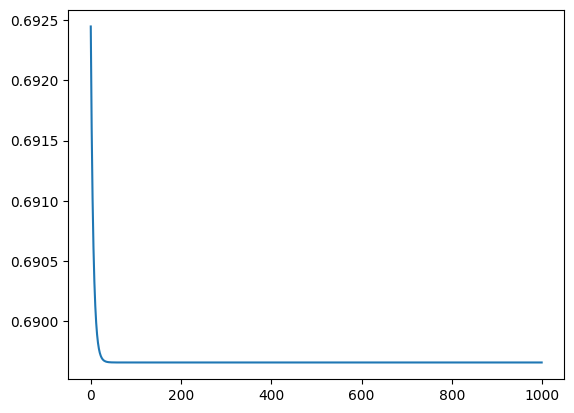

In [ ]:
w, losses_history = gradient_descent(X_train_scaled, y_train)
plt.plot(losses_history)
plt.show()

# Activity 4. Bài tập

### 1. Đánh giá mô hình hiện tại trên tập Test
Chúng ta sẽ sử dụng các trọng số `w` vừa tìm được để dự báo trên `X_test_scaled` và tính toán các chỉ số đo lường.

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

# Dự báo trên tập test
y_pred = predict(X_test_scaled, w)

# Tính toán các chỉ số
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")

Accuracy: 0.6500
Recall: 0.5714
Precision: 0.5000


### 2. Viết lại mô hình dưới dạng Class `LogisticRegression1`

In [ ]:
class LogisticRegression1:
    def __init__(self, lr=0.02, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.losses = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        self.w = np.zeros((1, X.shape[1]))
        self.losses = []
        m = X.shape[0]

        for _ in range(self.epochs):
            # Forward pass
            z = np.dot(X, self.w.T)
            y_hat = self._sigmoid(z)

            # Loss
            loss = -np.mean(y * np.log(y_hat + 1e-9) + (1 - y) * np.log(1 - y_hat + 1e-9))
            self.losses.append(loss)

            # Gradient
            dw = np.dot((y_hat - y).T, X) / m

            # Update
            self.w -= self.lr * dw

    def predict_prob(self, X):
        z = np.dot(X, self.w.T)
        return self._sigmoid(z)

    def predict(self, X):
        probs = self.predict_prob(X)
        return (probs >= 0.5).astype(int)

### 3. Mô hình Logistic Regression có hệ số Bias (Intercept)
Để thêm bias, chúng ta chỉ cần thêm một cột toàn số 1 vào ma trận đầu vào `X`.

In [ ]:
class LogisticRegressionWithBias(LogisticRegression1):
    def fit(self, X, y):
        # Thêm cột 1 vào X để đại diện cho bias
        X_bias = np.c_[np.ones(X.shape[0]), X]
        self.w = np.zeros((1, X_bias.shape[1]))
        self.losses = []
        m = X_bias.shape[0]

        for _ in range(self.epochs):
            z = np.dot(X_bias, self.w.T)
            y_hat = self._sigmoid(z)

            loss = -np.mean(y * np.log(y_hat + 1e-9) + (1 - y) * np.log(1 - y_hat + 1e-9))
            self.losses.append(loss)

            dw = np.dot((y_hat - y).T, X_bias) / m
            self.w -= self.lr * dw

    def predict(self, X):
        X_bias = np.c_[np.ones(X.shape[0]), X]
        probs = self._sigmoid(np.dot(X_bias, self.w.T))
        return (probs >= 0.5).astype(int)

# Huấn luyện và đánh giá mô hình có Bias
model_bias = LogisticRegressionWithBias(lr=0.1, epochs=2000)
model_bias.fit(X_train_scaled, y_train)
y_pred_bias = model_bias.predict(X_test_scaled)

print("--- Đánh giá mô hình có Bias ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bias):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_bias):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_bias):.4f}")

--- Đánh giá mô hình có Bias ---
Accuracy: 0.8750
Recall: 0.6786
Precision: 0.9500
